### Libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os


sns.set_style("whitegrid")
df = pd.read_csv("./cleaned_customer_support_tickets_200k.csv")

### MODULE 5

###  1. Average Resolution Time by Priority and Type

C:\Users\jithe\AppData\Local\Temp\ipykernel_12376\1737819986.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=avg_by_priority.index, y=avg_by_priority.values, palette="Reds_d")


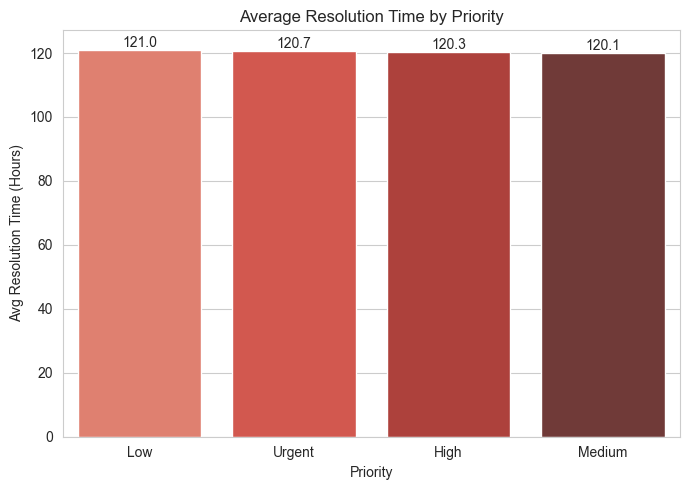

C:\Users\jithe\AppData\Local\Temp\ipykernel_12376\1737819986.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=avg_by_type.index, y=avg_by_type.values, palette="Blues_d")


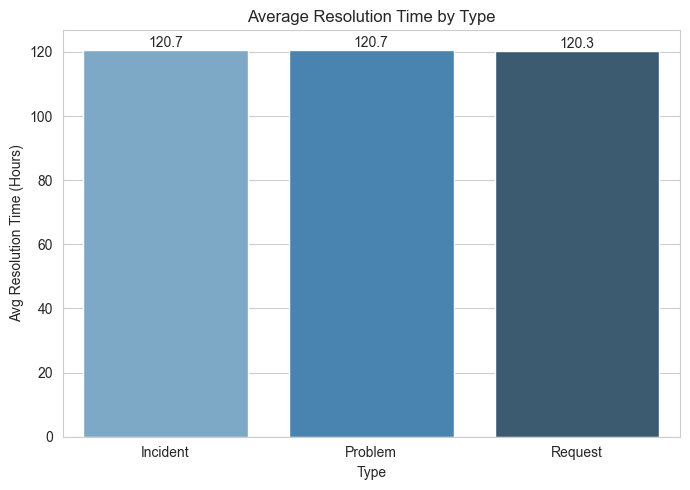

In [27]:
plt.figure(figsize=(7,5))
avg_by_priority = df.groupby("priority")["resolution_time_hours"].mean().sort_values(ascending=False)
ax = sns.barplot(x=avg_by_priority.index, y=avg_by_priority.values, palette="Reds_d")
plt.title("Average Resolution Time by Priority")
plt.xlabel("Priority")
plt.ylabel("Avg Resolution Time (Hours)")
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f"{x:.1f}")
plt.tight_layout()
plt.savefig("./images/M5/plot_avg_resolution_by_priority.png", dpi=200)
plt.show()

plt.figure(figsize=(7,5))
avg_by_type = df.groupby("type")["resolution_time_hours"].mean().sort_values(ascending=False)
ax = sns.barplot(x=avg_by_type.index, y=avg_by_type.values, palette="Blues_d")
plt.title("Average Resolution Time by Type")
plt.xlabel("Type")
plt.ylabel("Avg Resolution Time (Hours)")
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f"{x:.1f}")
plt.tight_layout()
plt.savefig("./images/M5/plot_avg_resolution_by_type.png", dpi=200)
plt.show()

###  2. Fastest Regions ("Countries") and Teams ("Queues")

C:\Users\jithe\AppData\Local\Temp\ipykernel_12376\3545763599.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=avg_by_region.values, y=avg_by_region.index, palette="crest")


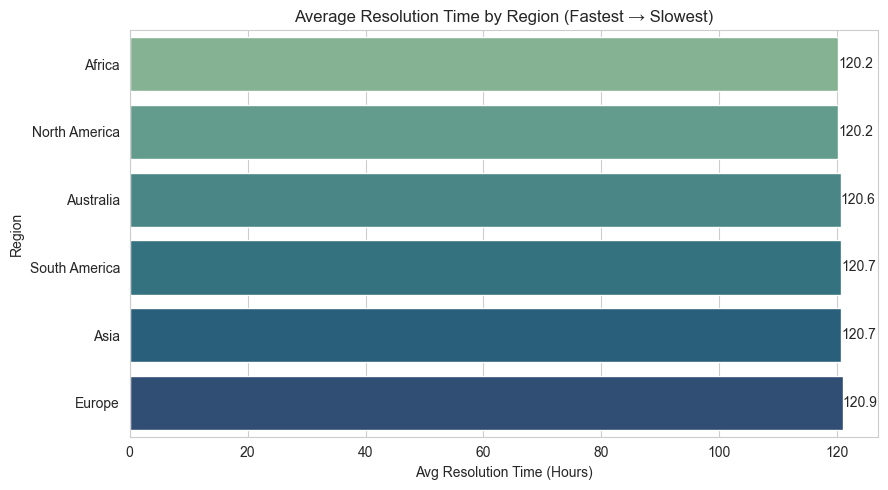

C:\Users\jithe\AppData\Local\Temp\ipykernel_12376\3545763599.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=avg_by_queue.values, y=avg_by_queue.index, palette="mako")


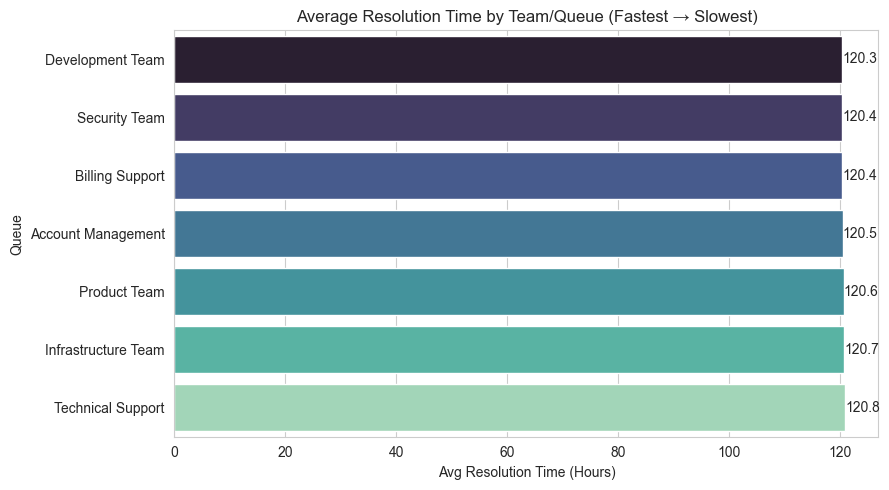

In [28]:
plt.figure(figsize=(9,5))
avg_by_region = df.groupby("region")["resolution_time_hours"].mean().sort_values()
ax = sns.barplot(x=avg_by_region.values, y=avg_by_region.index, palette="crest")
plt.title("Average Resolution Time by Region (Fastest → Slowest)")
plt.xlabel("Avg Resolution Time (Hours)")
plt.ylabel("Region")
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f"{x:.1f}")
plt.tight_layout()
plt.savefig("./images/M5/plot_avg_resolution_by_region.png", dpi=200)
plt.show()

plt.figure(figsize=(9,5))
avg_by_queue = df.groupby("queue")["resolution_time_hours"].mean().sort_values()
ax = sns.barplot(x=avg_by_queue.values, y=avg_by_queue.index, palette="mako")
plt.title("Average Resolution Time by Team/Queue (Fastest → Slowest)")
plt.xlabel("Avg Resolution Time (Hours)")
plt.ylabel("Queue")
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f"{x:.1f}")
plt.tight_layout()
plt.savefig("./images/M5/plot_avg_resolution_by_queue.png", dpi=200)
plt.show()

### 3. High-Priority Unresolved Issues

High/Urgent priority tickets still unresolved: 80,460


C:\Users\jithe\AppData\Local\Temp\ipykernel_12376\4224920088.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=status_breakdown.index, y=status_breakdown.values, palette="Oranges_d")


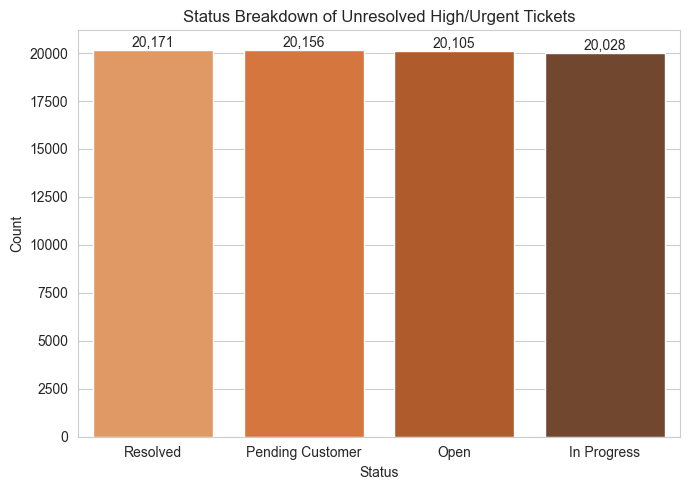

In [29]:
unresolved_high_priority = df[
    (df["priority"].isin(["High", "Urgent"])) &
    (df["status"] != "Closed")
]
print(f"High/Urgent priority tickets still unresolved: {len(unresolved_high_priority):,}")

plt.figure(figsize=(7,5))
status_breakdown = unresolved_high_priority["status"].value_counts()
ax = sns.barplot(x=status_breakdown.index, y=status_breakdown.values, palette="Oranges_d")
plt.title("Status Breakdown of Unresolved High/Urgent Tickets")
plt.xlabel("Status")
plt.ylabel("Count")
for container in ax.containers:
    ax.bar_label(container, fmt=lambda x: f"{int(x):,}")
plt.tight_layout()
plt.savefig("./images/M5/plot_unresolved_high_priority.png", dpi=200)
plt.show()

### MODULE 6

In [30]:
sns.set_style("whitegrid")
os.makedirs("images/M6", exist_ok=True)

### STEP 0: Confirm what 'region' actually contains

In [31]:
print("Unique regions:", df["region"].unique())
print("Number of regions:", df["region"].nunique())

Unique regions: <ArrowStringArray>
['North America', 'South America', 'Europe', 'Asia', 'Africa', 'Australia']
Length: 6, dtype: str
Number of regions: 6


### 1. Heatmap: Ticket Concentration by Region x Category

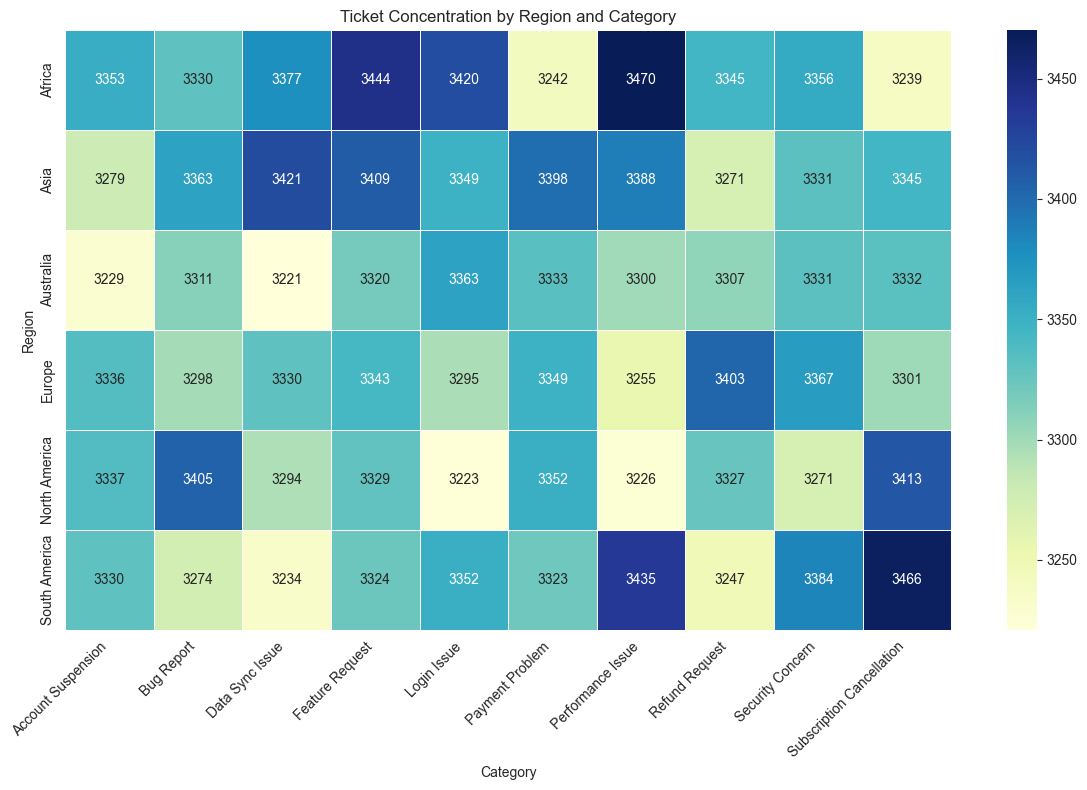

In [32]:
plt.figure(figsize=(12, 8))
region_category = pd.crosstab(df["region"], df["category"])
sns.heatmap(region_category, cmap="YlGnBu", annot=True, fmt="d", linewidths=0.5)
plt.title("Ticket Concentration by Region and Category")
plt.xlabel("Category")
plt.ylabel("Region")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("images/M6/plot1_region_category_heatmap.png", dpi=150)
plt.show()


### 2. Geographic Mapping — region -> country centroid lookup

In [33]:
import plotly.express as px

continent_map = {
    "Asia": "India",
    "Europe": "Germany",
    "North America": "United States",
    "South America": "Brazil",
    "Africa": "South Africa",
    "Australia": "Australia",
    "Oceania": "Australia"
}

region_summary = (
    df.groupby("region")
      .agg(
          ticket_count=("ticket_id", "count"),
          top_category=("category", lambda x: x.mode()[0])
      )
      .reset_index()
)

region_summary["country"] = region_summary["region"].map(continent_map)

fig = px.choropleth(
    region_summary,
    locations="country",
    locationmode="country names",
    color="top_category",
    hover_name="region",
    hover_data=["ticket_count"],
    title="Dominant Ticket Category by Region"
)
fig.write_html("images/M6/plot2_geo_category_map.html")
fig.show()

C:\Users\jithe\AppData\Local\Temp\ipykernel_12376\1763639754.py:24: DeprecationWarning: The library used by the *country names* `locationmode` option is changing in an upcoming version. Country names in existing plots may not work in the new version. To ensure consistent behavior, consider setting `locationmode` to *ISO-3*.
  fig = px.choropleth(


### 3. Cluster Size vs Performance Score

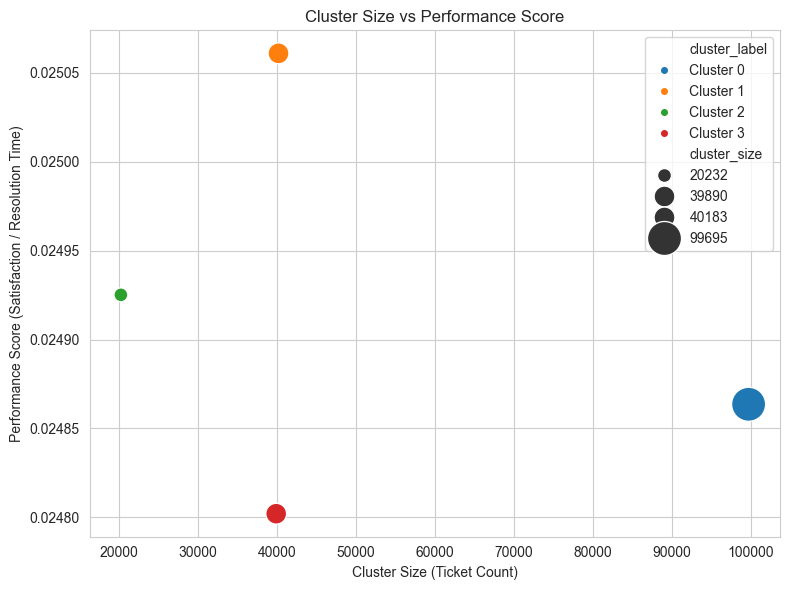

  cluster_label  cluster_size  avg_resolution_time  avg_satisfaction  \
0     Cluster 0         99695           120.753885          3.002377   
1     Cluster 1         40183           119.705125          2.999925   
2     Cluster 2         20232           120.475418          3.002867   
3     Cluster 3         39890           120.877797          2.998020   

   avg_similarity  performance_score  
0        0.447201           0.024864  
1        0.742350           0.025061  
2        1.000000           0.024925  
3        0.753322           0.024802  


In [34]:
clustered = pd.read_csv("clustered_tickets.csv")  # from Module 4 output

cluster_summary = clustered.groupby("cluster_label").agg(
    cluster_size=("ticket_id", "count"),
    avg_resolution_time=("resolution_time_hours", "mean"),
    avg_satisfaction=("customer_satisfaction_score", "mean"),
    avg_similarity=("similarity_score", "mean"),
).reset_index()

cluster_summary["performance_score"] = (
    cluster_summary["avg_satisfaction"] / cluster_summary["avg_resolution_time"]
)

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=cluster_summary, x="cluster_size", y="performance_score",
    size="cluster_size", hue="cluster_label", palette="tab10",
    legend="full", sizes=(100, 600)
)
plt.title("Cluster Size vs Performance Score")
plt.xlabel("Cluster Size (Ticket Count)")
plt.ylabel("Performance Score (Satisfaction / Resolution Time)")
plt.tight_layout()
plt.savefig("images/M6/plot3_cluster_size_vs_performance.png", dpi=150)
plt.show()

print(cluster_summary)



### 4. Performance Metrics Summary (deliverable)

In [35]:
performance_summary = df.groupby("region").agg(
    ticket_count=("ticket_id", "count"),
    avg_resolution_time=("resolution_time_hours", "mean"),
    avg_first_response=("first_response_time_hours", "mean"),
    avg_satisfaction=("customer_satisfaction_score", "mean"),
).sort_values("avg_resolution_time")

performance_summary.to_csv("images/M6/performance_metrics_summary.csv")
print(performance_summary)

               ticket_count  avg_resolution_time  avg_first_response  \
region                                                                 
Africa                33576           120.206789           36.408282   
North America         33177           120.208662           36.381035   
Australia             33047           120.576541           36.430527   
South America         33369           120.660512           36.214094   
Asia                  33554           120.666593           36.174085   
Europe                33277           120.920070           36.248607   

               avg_satisfaction  
region                           
Africa                 2.990410  
North America          3.001839  
Australia              3.002965  
South America          3.004465  
Asia                   2.998420  
Europe                 3.008414  


### 5. Comparative Charts — Region Performance Comparison

C:\Users\jithe\AppData\Local\Temp\ipykernel_12376\1872540279.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax0 = sns.barplot(data=region_perf, x="avg_resolution_time", y="region", palette="crest", ax=axes[0])
C:\Users\jithe\AppData\Local\Temp\ipykernel_12376\1872540279.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax1 = sns.barplot(data=region_perf, x="avg_satisfaction", y="region", palette="rocket", ax=axes[1])


<Figure size 1000x600 with 0 Axes>

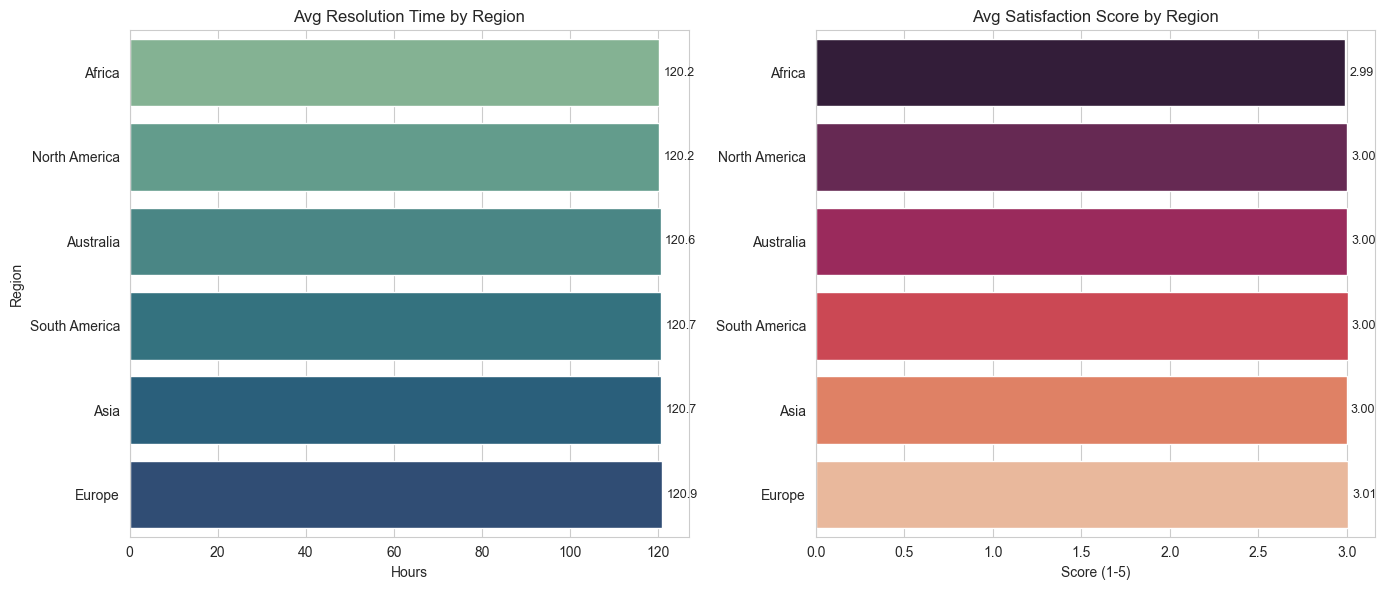

In [36]:
plt.figure(figsize=(10, 6))
region_perf = df.groupby("region").agg(
    avg_resolution_time=("resolution_time_hours", "mean"),
    avg_satisfaction=("customer_satisfaction_score", "mean"),
).reset_index().sort_values("avg_resolution_time")

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax0 = sns.barplot(data=region_perf, x="avg_resolution_time", y="region", palette="crest", ax=axes[0])
axes[0].set_title("Avg Resolution Time by Region")
axes[0].set_xlabel("Hours")
axes[0].set_ylabel("Region")
for container in ax0.containers:
    ax0.bar_label(container, fmt=lambda x: f"{x:.1f}", fontsize=9, padding=3)

ax1 = sns.barplot(data=region_perf, x="avg_satisfaction", y="region", palette="rocket", ax=axes[1])
axes[1].set_title("Avg Satisfaction Score by Region")
axes[1].set_xlabel("Score (1-5)")
axes[1].set_ylabel("")
for container in ax1.containers:
    ax1.bar_label(container, fmt=lambda x: f"{x:.2f}", fontsize=9, padding=3)

plt.tight_layout()
plt.savefig("images/M6/plot4_region_comparison.png", dpi=150)
plt.show()
